# Setup

In [1]:
%load_ext autoreload
%autoreload 2

# %matplotlib widget

In [2]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import logging
import tpvalidator.workspace as workspace
# import tpvalidator.utils as utils
import tpvalidator.analyzers.snn as snn

from rich import print
from tpvalidator.utils import temporary_log_level, pandas_backend


# Argon 39 dataset

In [3]:
import tpvalidator.datasetloader as dsl

ar39_ds = 'ar39_5e_00'
datasets = dsl.load('data/vd/1x8x14', [ar39_ds])



Adding rawadcs/trigger_digits_waves_detsim_tpc_vd_ar39_1x8x14.root

Dataset 'ar39_5e_00': 5 events

{
    'backtracker': {'TPAlgTPCSimpleThreshold': {'offset_U': 8, 'offset_V': 1, 'offset_X': -7}},
    'geo': {'detector': 'dunevd10kt_3view_30deg_v5_refactored_1x8x14ref'},
    'mctruth_blockid_map': [[0, 'Ar39GenInLAr']],
    'tpg': {
        'tpmakerTPCSimpleThreshold::TriggerPrimitiveMaker': {
            'threshold_tpg_plane0': 27,
            'threshold_tpg_plane1': 27,
            'threshold_tpg_plane2': 27,
            'tool': 'TPAlgTPCSimpleThreshold'
        }
    }
}

In [4]:
# from pathlib import Path
# pre_prod_dir = Path('../../data/vd/pre_prod/')
# with temporary_log_level(workspace.TriggerPrimitivesWorkspace._log, logging.WARN):
#     ar39_ws = workspace.TriggerPrimitivesWorkspace(pre_prod_dir / 'anatree_vd_ar39_hist.root')

# ar39_ws.add_rawdigits(pre_prod_dir / 'rawdigits' / 'trigger_digits_waves_detsim_vd_ar39.root')

# print(ar39_ws.info)

ws=datasets[ar39_ds]

# SimIDEs properties

In [5]:
ws.simides

event    run  subrun  channel  timestamp  numelectrons  \
entry subentry                                                           
0     0             1  99100       0    95929       5847     14.982395   
      1             1  99100       0    95929       5848     60.191978   
      2             1  99100       0    95929       5849    152.936722   
      3             1  99100       0    95929       5850    262.542145   
      4             1  99100       0    95929       5851    304.597198   
...               ...    ...     ...      ...        ...           ...   
4     589280        5  99100       0      863       6828   1224.370483   
      589281        5  99100       0      863       6829    750.055298   
      589282        5  99100       0      863       6830    319.330231   
      589283        5  99100       0      863       6831     94.450256   
      589284        5  99100       0      863       6832     15.626792   

                  energy          x           y            z  trackID  \
entry subentry                                                          
0     0         0.065443 -10.863844  508.063751  1989.546265     4579   
      1         0.314341 -10.863998  508.063934  1989.546387     4579   
      2         0.797611 -10.864011  508.063934  1989.546265     4579   
      3         1.367429 -10.864023  508.063904  1989.546387     4579   
      4         1.584408 -10.864038  508.063904  1989.546265     4579   
...                  ...        ...         ...          ...      ...   
4     589280    2.374405 -35.971951 -655.577148   149.556015    23371   
      589281    1.472897 -35.972023 -655.577271   149.556091    23371   
      589282    0.635040 -35.972092 -655.577393   149.556183    23371   
      589283    0.190235 -35.972160 -655.577454   149.556274    23371   
      589284    0.021321 -35.970589 -655.575317   149.554184    23371   

                origTrackID  readout_plane_id  readout_view  detector_element  \
entry subentry                                                                  
0     0              4579.0               0.0           0.0             111.0   
      1              4579.0               0.0           0.0             111.0   
      2              4579.0               0.0           0.0             111.0   
      3              4579.0               0.0           0.0             111.0   
      4              4579.0               0.0           0.0             111.0   
...                     ...               ...           ...               ...   
4     589280        23371.0               2.0           2.0               0.0   
      589281        23371.0               2.0           2.0               0.0   
      589282        23371.0               2.0           2.0               0.0   
      589283        23371.0               2.0           2.0               0.0   
      589284        23371.0               2.0           2.0               0.0   

                event_uid  
entry subentry             
0     0         315752193  
      1         315752193  
      2         315752193  
      3         315752193  
      4         315752193  
...                   ...  
4     589280    315752197  
      589281    315752197  
      589282    315752197  
      589283    315752197  
      589284    315752197  

[2935086 rows x 16 columns]

array([[<Axes: title={'center': 'event'}>,
        <Axes: title={'center': 'run'}>,
        <Axes: title={'center': 'subrun'}>,
        <Axes: title={'center': 'channel'}>],
       [<Axes: title={'center': 'timestamp'}>,
        <Axes: title={'center': 'numelectrons'}>,
        <Axes: title={'center': 'energy'}>,
        <Axes: title={'center': 'x'}>],
       [<Axes: title={'center': 'y'}>, <Axes: title={'center': 'z'}>,
        <Axes: title={'center': 'trackID'}>,
        <Axes: title={'center': 'origTrackID'}>],
       [<Axes: title={'center': 'readout_plane_id'}>,
        <Axes: title={'center': 'readout_view'}>,
        <Axes: title={'center': 'detector_element'}>,
        <Axes: title={'center': 'event_uid'}>]], dtype=object)

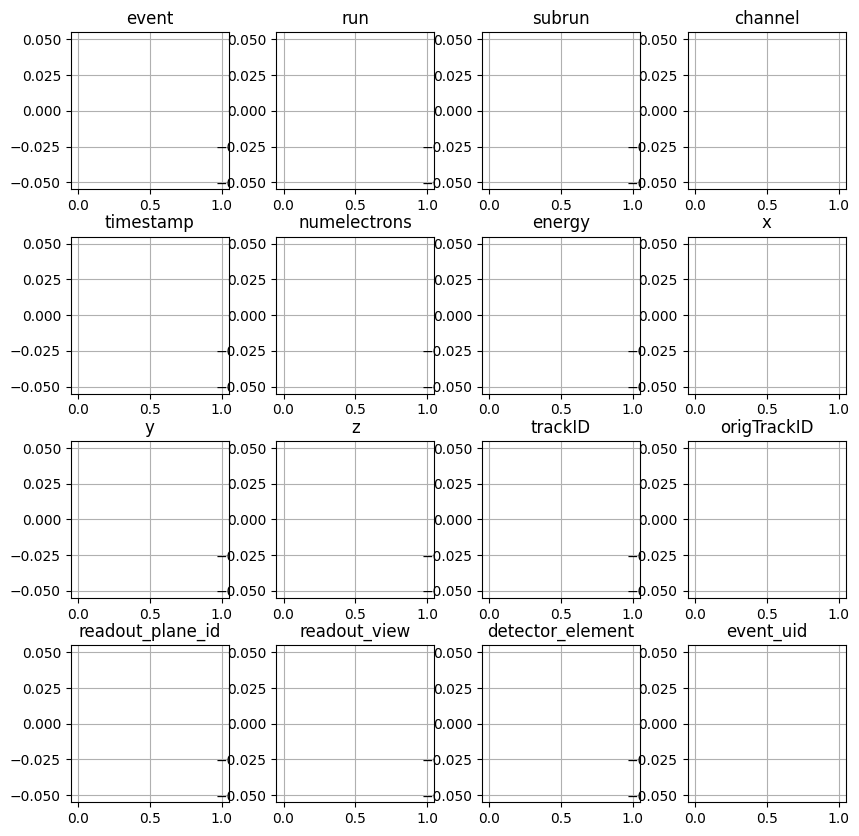

In [6]:
ws.simides.query('timestamp > 9000').hist(figsize=(10,10), bins=100)

### SimIDEs distributions
Overview amd focus on the start and end of the readout window

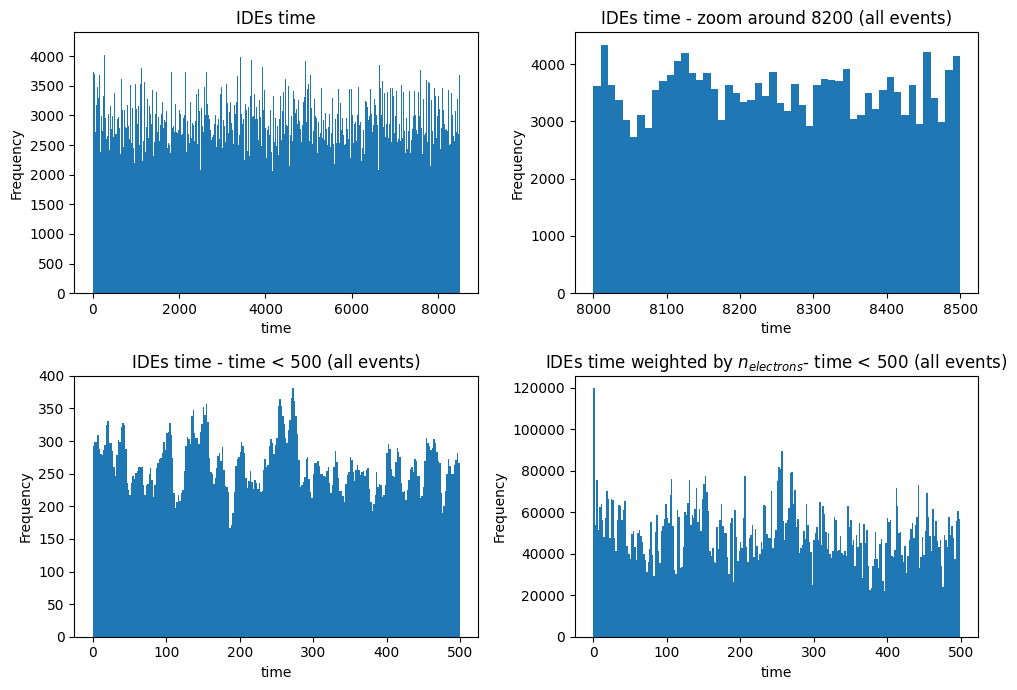

In [7]:
fig, axes = plt.subplots(2,2, squeeze=False, figsize=(10,7))

ax = axes[0,0]
# ws.simides.query('event==1').timestamp.plot.hist(bins=1000, ax=ax)
ws.simides.timestamp.plot.hist(bins=1000, ax=ax)
ax.set_xlabel('time')
ax.set_title('IDEs time')

ax = axes[0,1]
bins=list(range(8000, 8501, 10))
ws.simides.query('timestamp > 8000 & timestamp < 8500').timestamp.plot.hist(bins=bins, ax=ax)
ax.set_xlabel('time')
ax.set_title('IDEs time - zoom around 8200 (all events)')

early_ides = ws.simides.query('timestamp <  500 & readout_view ==2')

ax = axes[1,0]
early_ides.timestamp.plot.hist(bins=250, ax=ax)
ax.set_xlabel('time')
ax.set_title('IDEs time - time < 500 (all events)')

ax = axes[1,1]
early_ides.timestamp.plot.hist(bins=250, weights=early_ides.numelectrons, ax=ax)
ax.set_xlabel('time')
ax.set_title('IDEs time weighted by $n_{electrons}$- time < 500 (all events)')

fig.tight_layout()


### SimIDEs outside readout window (t>> 8500)

fig, axes = plt.subplots()
std_ides = ws.simides.query('timestamp < 60000')
t_min = std_ides.timestamp.min()
t_max = std_ides.timestamp.max()
print(f"stdctimestamp range (>60k) : {t_min}-{t_max}")

odd_ides = ws.simides.query('timestamp > 60000')

t_min = odd_ides.timestamp.min()
t_max = odd_ides.timestamp.max()
print(f"odd timestamp range (>60k) : {t_min}-{t_max}")

bins = (t_max-t_min)-1
odd_ides.timestamp.hist(bins=bins, ax=axes)

### Comparing distributions

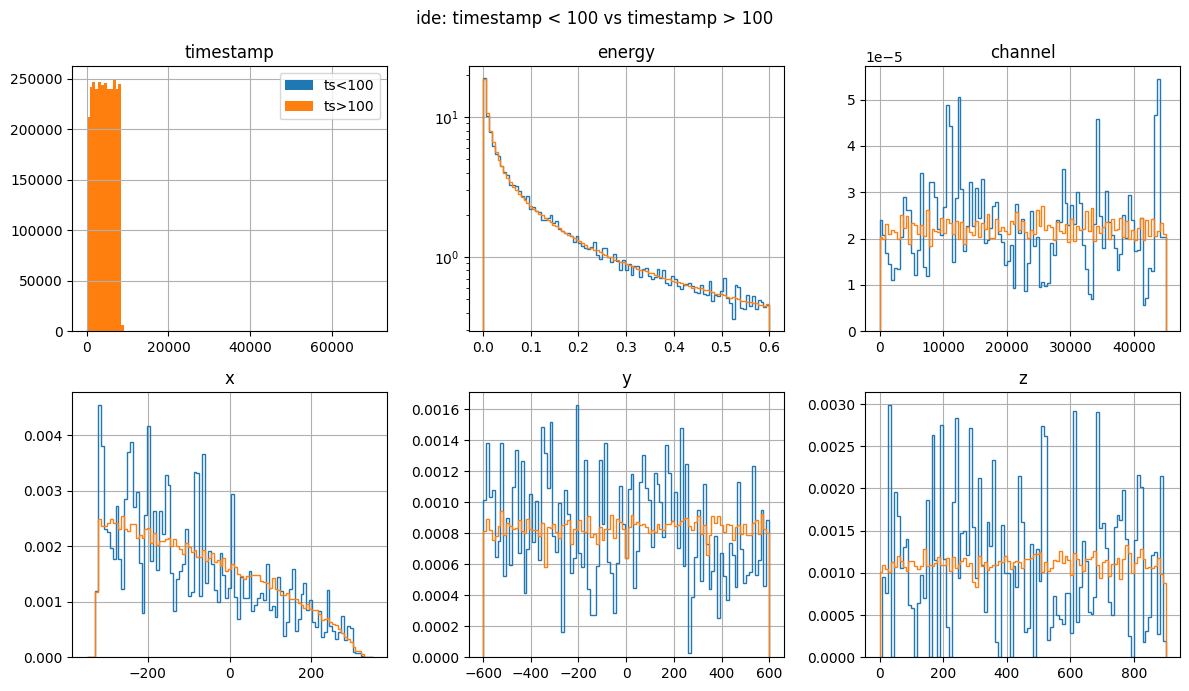

In [8]:
fig,axes = plt.subplots(2,3, figsize=(12,7))

edge=100
q1=f'timestamp < {edge} & event<100'
q2=f'timestamp > {edge} & event<100'


bins=np.linspace(0, 70000, 100)

ax=axes[0][0]
ws.simides.query(q1).timestamp.hist(ax=ax, bins=bins, label=f'ts<{edge}')
ws.simides.query(q2).timestamp.hist(ax=ax, bins=bins, label=f'ts>{edge}')
ax.legend()

ax.set_title('timestamp')


bins=np.linspace(0, 0.6, 100)

ax=axes[0][1]
ws.simides.query(q1).energy.hist(ax=ax, bins=bins, histtype='step', density=True)
ws.simides.query(q2).energy.hist(ax=ax, bins=bins, histtype='step', density=True)
ax.set_title('energy')
ax.set_yscale('log')


bins=np.linspace(0, 45000, 100)

ax=axes[0][2]
ws.simides.query(q1).channel.hist(ax=ax, bins=bins, histtype='step', density=True)
ws.simides.query(q2).channel.hist(ax=ax, bins=bins, histtype='step', density=True)
ax.set_title('channel')


bins=np.linspace(-350, 350, 100)

ax=axes[1][0]
ws.simides.query(q1).x.hist(ax=ax, bins=bins, histtype='step', density=True)
ws.simides.query(q2).x.hist(ax=ax, bins=bins, histtype='step', density=True)
ax.set_title('x')


bins=np.linspace(-600, 600, 100)

ax=axes[1][1]
ws.simides.query(q1).y.hist(ax=ax, bins=bins, histtype='step', density=True)
ws.simides.query(q2).y.hist(ax=ax, bins=bins, histtype='step', density=True)
ax.set_title('y')


bins=np.linspace(0, 900, 100)

ax=axes[1][2]
ws.simides.query(q1).z.hist(ax=ax, bins=bins, histtype='step', density=True)
ws.simides.query(q2).z.hist(ax=ax, bins=bins, histtype='step', density=True)
ax.set_title('z')

fig.suptitle(f'ide: timestamp < {edge} vs timestamp > {edge}')
fig.tight_layout()


/Users/ale/Development/dune/trigger-studies/tpvalidator/.venv/lib/python3.13/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges
/Users/ale/Development/dune/trigger-studies/tpvalidator/.venv/lib/python3.13/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges
/Users/ale/Development/dune/trigger-studies/tpvalidator/.venv/lib/python3.13/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges
/Users/ale/Development/dune/trigger-studies/tpvalidator/.venv/lib/python3.13/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges
/Users/ale/Development/dune/trigger-studies/tpvalidator/.venv/lib/python3.13/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning

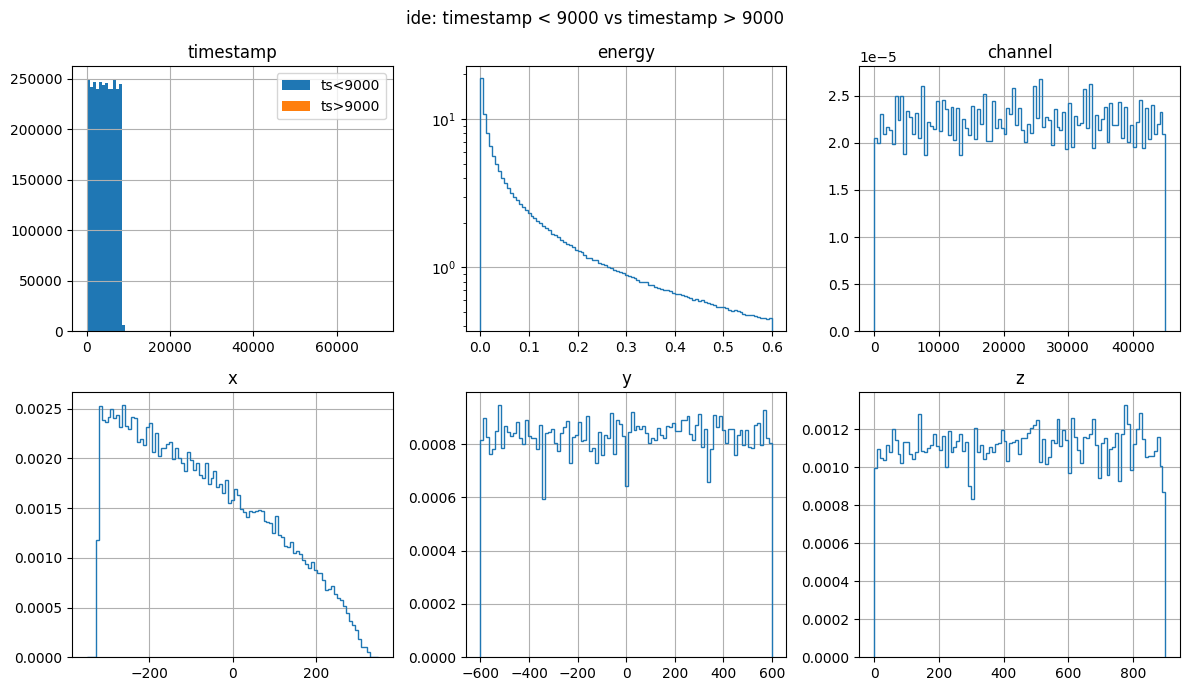

In [9]:
fig,axes = plt.subplots(2,3, figsize=(12,7))

edge=9000
q1=f'timestamp < {edge} & event<100'
q2=f'timestamp > {edge} & event<100'


bins=np.linspace(0, 70000, 100)

ax=axes[0][0]
ws.simides.query(q1).timestamp.hist(ax=ax, bins=bins, label=f'ts<{edge}')
ws.simides.query(q2).timestamp.hist(ax=ax, bins=bins, label=f'ts>{edge}')
ax.legend()

ax.set_title('timestamp')


bins=np.linspace(0, 0.6, 100)

ax=axes[0][1]
ws.simides.query(q1).energy.hist(ax=ax, bins=bins, histtype='step', density=True)
ws.simides.query(q2).energy.hist(ax=ax, bins=bins, histtype='step', density=True)
ax.set_title('energy')
ax.set_yscale('log')


bins=np.linspace(0, 45000, 100)

ax=axes[0][2]
ws.simides.query(q1).channel.hist(ax=ax, bins=bins, histtype='step', density=True)
ws.simides.query(q2).channel.hist(ax=ax, bins=bins, histtype='step', density=True)
ax.set_title('channel')


bins=np.linspace(-350, 350, 100)

ax=axes[1][0]
ws.simides.query(q1).x.hist(ax=ax, bins=bins, histtype='step', density=True)
ws.simides.query(q2).x.hist(ax=ax, bins=bins, histtype='step', density=True)
ax.set_title('x')


bins=np.linspace(-600, 600, 100)

ax=axes[1][1]
ws.simides.query(q1).y.hist(ax=ax, bins=bins, histtype='step', density=True)
ws.simides.query(q2).y.hist(ax=ax, bins=bins, histtype='step', density=True)
ax.set_title('y')


bins=np.linspace(0, 900, 100)

ax=axes[1][2]
ws.simides.query(q1).z.hist(ax=ax, bins=bins, histtype='step', density=True)
ws.simides.query(q2).z.hist(ax=ax, bins=bins, histtype='step', density=True)
ax.set_title('z')

fig.suptitle(f'ide: timestamp < {edge} vs timestamp > {edge}')
fig.tight_layout()


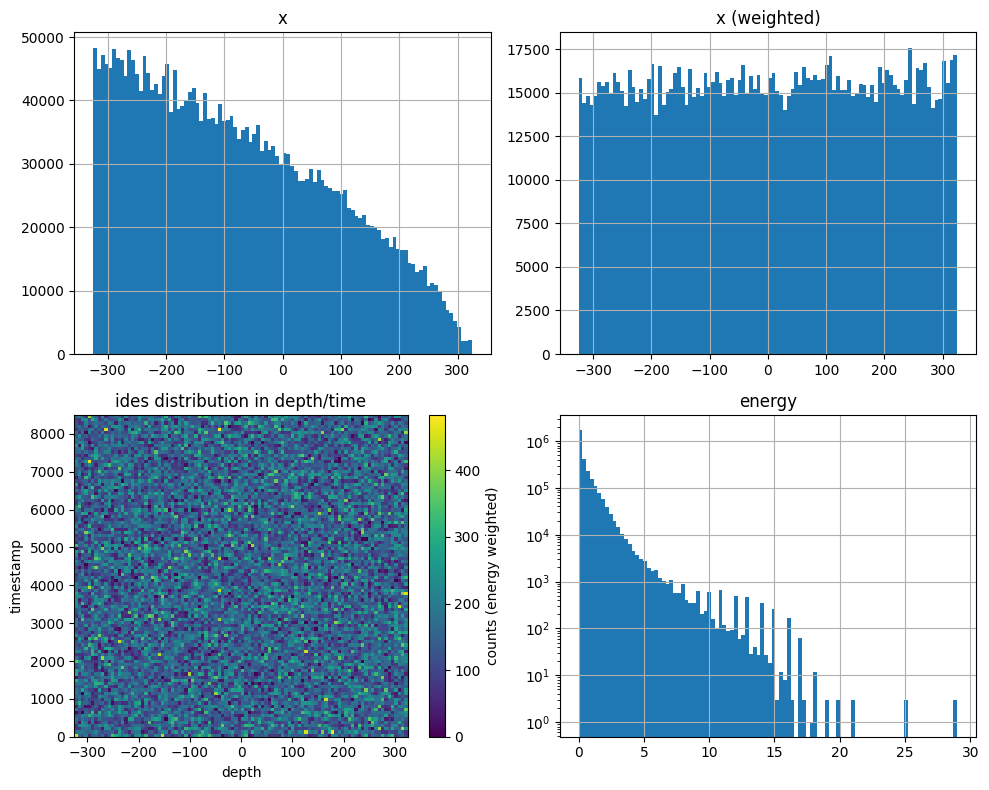

In [10]:
import matplotlib as mpl
fig, axes = plt.subplots(2,2, figsize=(10,8))
norm=mpl.colors.LogNorm()

ides_clean = ws.simides.query('timestamp < 10000')


ax=axes[0][0]
ides_clean.x.hist(bins=100, ax=ax)
ax.set_title('x')

ax=axes[0][1]
ides_clean.x.hist(bins=100, weights=ides_clean.energy, ax=ax)
ax.set_title('x (weighted)')

ax = axes[1][0]
h2d = ax.hist2d(ides_clean.x, ides_clean.timestamp, weights=ides_clean.energy, bins=(100, 100))
ax.set_ylabel('timestamp')
ax.set_xlabel('depth')
cbar = fig.colorbar(h2d[3], ax=ax)
cbar.set_label('counts (energy weighted)')
ax.set_title('ides distribution in depth/time')

ax=axes[1][1]
ides_clean.energy.hist(ax=ax, bins=100)
ax.set_title('energy')
ax.set_yscale('log')

fig.tight_layout()

-4249983.2808971405 4249996.453523636

Text(0.5, 1.0, 'mc particles generation time distribution')

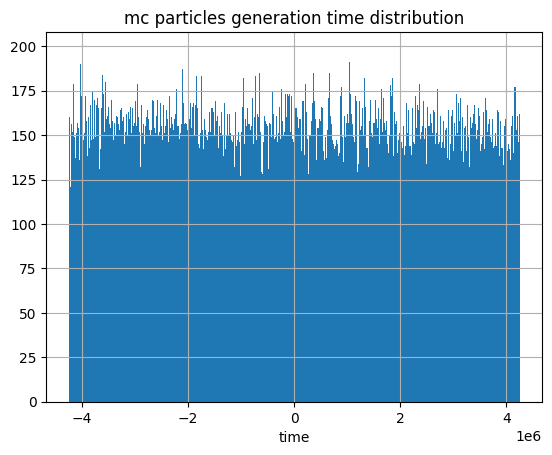

In [11]:
print(ws.mcparticles.t.min(), ws.mcparticles.t.max())

fig, axes = plt.subplots(1,1, squeeze=False)

ax = axes[0,0]
ws.mcparticles.t.hist(ax=ax, bins=1000)
ax.set_xlabel('time')
ax.set_title('mc particles generation time distribution')

# ADCs

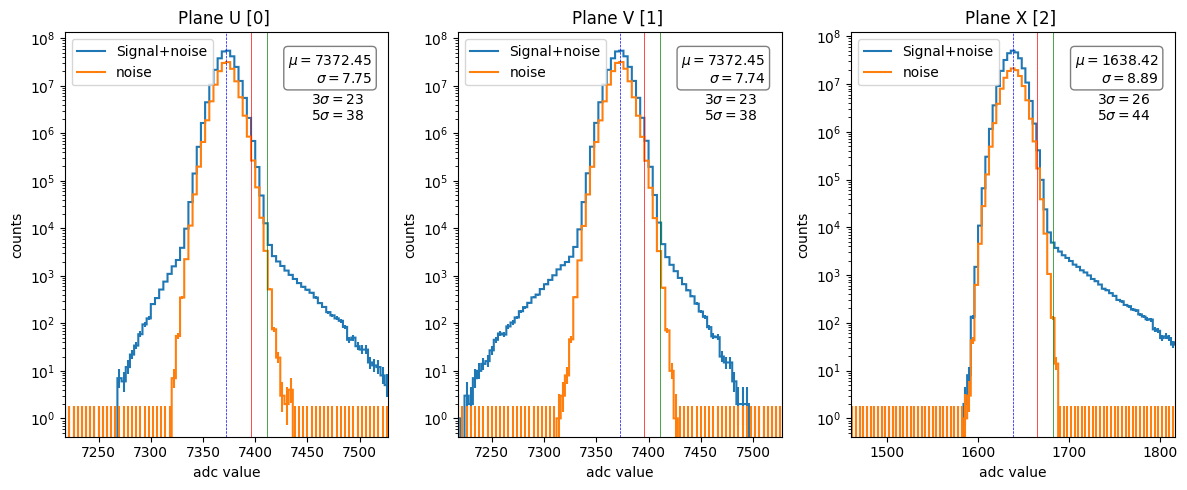

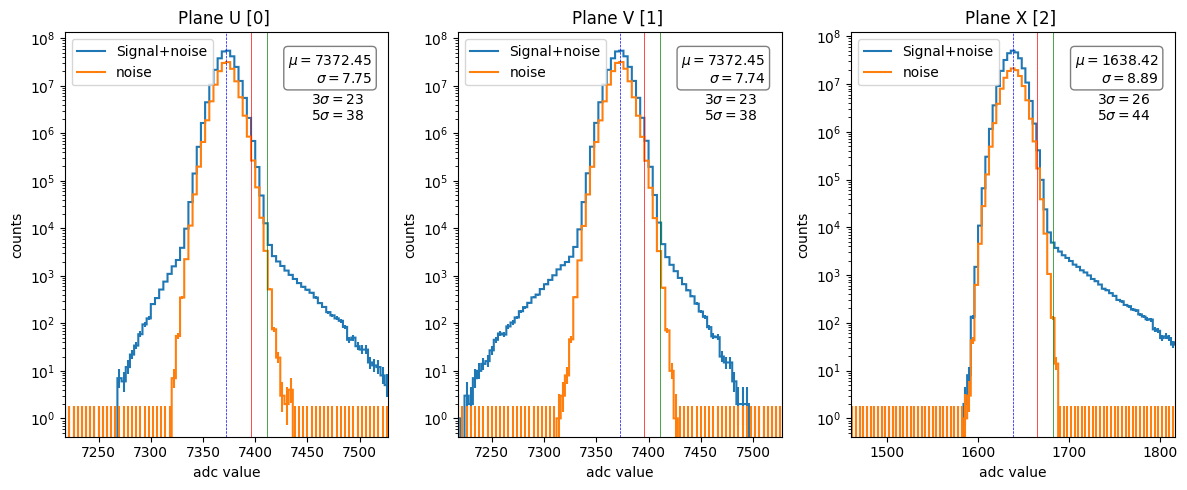

In [5]:
snn.draw_signal_and_noise_adc_distros(ws)

## Trigger primitives

In [6]:
ws.tps

event    run  subrun  version  flag  detid  channel  \
entry subentry                                                        
0     0             1  99100       0        2     0      3    95939   
      1             1  99100       0        2     0      3    95939   
      2             1  99100       0        2     0      3    95940   
      3             1  99100       0        2     0      3    95944   
      4             1  99100       0        2     0      3    95947   
...               ...    ...     ...      ...   ...    ...      ...   
4     633960        5  99100       0        2     0      3      863   
      633961        5  99100       0        2     0      3      863   
      633962        5  99100       0        2     0      3      863   
      633963        5  99100       0        2     0      3      863   
      633964        5  99100       0        2     0      3      863   

                samples_over_threshold  time_start  samples_to_peak  ...  \
entry subentry                                                       ...   
0     0                              1      198080                0  ...   
      1                              1      262720                0  ...   
      2                              2      188864                0  ...   
      3                              1      174400                0  ...   
      4                              1      114208                0  ...   
...                                ...         ...              ...  ...   
4     633960                         1       35072                0  ...   
      633961                         2      166784                0  ...   
      633962                         8      218592                4  ...   
      633963                         1      238496                0  ...   
      633964                         3      245248                0  ...   

                bt_primary_x  bt_primary_y  bt_primary_z  bt_truth_block_id  \
entry subentry                                                                
0     0        -99999.000000 -99999.000000 -99999.000000             -99999   
      1        -99999.000000 -99999.000000 -99999.000000             -99999   
      2           259.010712    531.257385   1965.911255                  0   
      3        -99999.000000 -99999.000000 -99999.000000             -99999   
      4        -99999.000000 -99999.000000 -99999.000000             -99999   
...                      ...           ...           ...                ...   
4     633960   -99999.000000 -99999.000000 -99999.000000             -99999   
      633961   -99999.000000 -99999.000000 -99999.000000             -99999   
      633962      -35.971897   -655.577026    149.555923                  0   
      633963   -99999.000000 -99999.000000 -99999.000000             -99999   
      633964   -99999.000000 -99999.000000 -99999.000000             -99999   

                bt_generator_name  event_uid  time_peak  sample_start  \
entry subentry                                                          
0     0                            315752193     198080          6190   
      1                            315752193     262720          8210   
      2              Ar39GenInLAr  315752193     188864          5902   
      3                            315752193     174400          5450   
      4                            315752193     114208          3569   
...                           ...        ...        ...           ...   
4     633960                       315752197      35072          1096   
      633961                       315752197     166784          5212   
      633962         Ar39GenInLAr  315752197     218720          6831   
      633963                       315752197     238496          7453   
      633964                       315752197     245248          7664   

                sample_peak  bt_is_signal  
entry subentry                             
0     0                6190          

In [7]:
ws.tps.query('readout_plane_id == 2 & bt_is_signal == 1 & samples_over_threshold<5').bt_numelectrons.sum()/ws.tps.query('readout_plane_id == 2 & bt_is_signal == 1').bt_numelectrons.sum()

# ws.tps.columns

np.float64(0.1262805488548455)

In [8]:
pd.options.plotting.backend = 'plotly'
import plotly.express as px



pd.options.plotting.backend = 'matplotlib'
with pandas_backend('plotly') as x:
    df = ws.tps.copy()
    df['bt_is_signal'] = df.bt_is_signal.astype(bool)
    f = df.query('entry==0').query('readout_plane_id == 2 & adc_peak > 36').plot.scatter(x='channel', y='sample_start', size='samples_over_threshold', color="bt_is_signal", color_continuous_scale=px.colors.sequential.Viridis, height=800, width=900)
    f.show()


In [9]:
pd.options.plotting.backend = 'plotly'
import plotly.express as px

pd.options.plotting.backend = 'matplotlib'
with pandas_backend('plotly') as x:
    f = ws.tps.query('entry==0 & sample_start < 200 & readout_plane_id == 2').plot.scatter(x='channel', y='sample_start', size='adc_peak', color="bt_is_signal", color_continuous_scale=px.colors.sequential.Viridis, height=800, width=900)
    f.show()


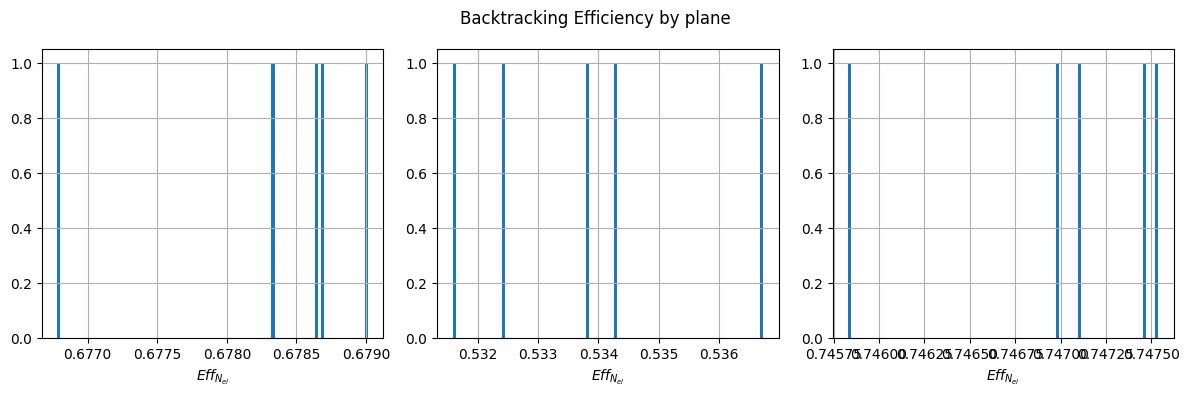

In [11]:
fig = btp.draw_eff_by_plane(bins=100)

fig.tight_layout()

# Backtracker checks

In [82]:
from tpvalidator.detector_geometry import FDVDGeometry_1x8x14

FDVDGeometry_1x8x14.tpc_view_channel_range(2)

FDVDGeometry_1x8x14.geo()

{'cryostat': {'origin': {'x': 0.03999999999990678,
   'y': -1.1368683772161603e-13,
   'z': 1045.94},
  'x_range': {'max': 425.19999999999993, 'min': -425.1200000000001},
  'y_range': {'max': 753.9223999999999, 'min': -753.9224000000002},
  'z_range': {'max': 2199.0, 'min': -107.11999999999989}},
 'detector_name': 'dunevd10kt_3view_30deg_v5_refactored_1x8x14ref',
 'opdets': [{'height': 60.0,
   'length': 1.0,
   'origin': {'x': 285.0699999999999, 'y': 219.9999999999999, 'z': 2188.38},
   'width': 60.0},
  {'height': 60.0,
   'length': 1.0,
   'origin': {'x': 285.0699999999999, 'y': -220.0000000000001, 'z': 2188.38},
   'width': 60.0},
  {'height': 1.0,
   'length': 60.0,
   'origin': {'x': 285.0699999999999, 'y': 743.3023999999999, 'z': 1939.46},
   'width': 60.0},
  {'height': 1.0,
   'length': 60.0,
   'origin': {'x': 285.0699999999999, 'y': -743.3024000000001, 'z': 1939.46},
   'width': 60.0},
  {'height': 1.0,
   'length': 60.0,
   'origin': {'x': 285.0699999999999, 'y': 743.302399

In [79]:
import tpvalidator.rootio.reader as reader
with temporary_log_level(reader._log, logging.DEBUG):
    rwdf = ws.rawdigits_tree.to_df(1, list(range(*FDVDGeometry_1x8x14.tpc_view_channel_range(2))))


INFO:tpvalidator.rootio.reader:Loading dense ADC
DEBUG:tpvalidator.rootio.reader:found 292 channels
DEBUG:tpvalidator.rootio.reader:Loading tree into np arrays
DEBUG:tpvalidator.rootio.reader:Done loading tree into np arrays
DEBUG:tpvalidator.rootio.reader:Converting np arrays to dataframe
DEBUG:tpvalidator.rootio.reader:Done converting np arrays to dataframe
DEBUG:tpvalidator.rootio.reader:Expanding waveforms
DEBUG:tpvalidator.rootio.reader:Done expanding waveforms


In [ ]:
ar39_wf = ws.get_rawadcs(1,list(range(*FDVDGeometry_1x8x14.tpc_view_channel_range(2))))


{'channel_mask': [572, 573, 574, 575, 576, 577, 578, 579, 580, 581, 582, 583, 584, 585, 586, 587, 588, 589, 590, 591, 592, 593, 594, 595, 596, 597, 598, 599, 600, 601, 602, 603, 604, 605, 606, 607, 608, 609, 610, 611, 612, 613, 614, 615, 616, 617, 618, 619, 620, 621, 622, 623, 624, 625, 626, 627, 628, 629, 630, 631, 632, 633, 634, 635, 636, 637, 638, 639, 640, 641, 642, 643, 644, 645, 646, 647, 648, 649, 650, 651, 652, 653, 654, 655, 656, 657, 658, 659, 660, 661, 662, 663, 664, 665, 666, 667, 668, 669, 670, 671, 672, 673, 674, 675, 676, 677, 678, 679, 680, 681, 682, 683, 684, 685, 686, 687, 688, 689, 690, 691, 692, 693, 694, 695, 696, 697, 698, 699, 700, 701, 702, 703, 704, 705, 706, 707, 708, 709, 710, 711, 712, 713, 714, 715, 716, 717, 718, 719, 720, 721, 722, 723, 724, 725, 726, 727, 728, 729, 730, 731, 732, 733, 734, 735, 736, 737, 738, 739, 740, 741, 742, 743, 744, 745, 746, 747, 748, 749, 750, 751, 752, 753, 754, 755, 756, 757, 758, 759, 760, 761, 762, 763, 764, 765, 766, 767, 76

event    run  subrun   572   573   574   575   576   577   578  ...   855  \
0       1  99100       0  1641  1630  1632  1637  1638  1633  1640  ...  1639   
0       1  99100       0  1648  1635  1638  1636  1637  1636  1643  ...  1626   
0       1  99100       0  1647  1638  1633  1636  1641  1642  1638  ...  1634   
0       1  99100       0  1652  1643  1632  1634  1649  1638  1632  ...  1639   
0       1  99100       0  1655  1644  1631  1638  1647  1641  1631  ...  1637   
..    ...    ...     ...   ...   ...   ...   ...   ...   ...   ...  ...   ...   
0       1  99100       0  1641  1623  1653  1622  1621  1643  1642  ...  1643   
0       1  99100       0  1635  1634  1652  1625  1620  1646  1644  ...  1648   
0       1  99100       0  1631  1641  1646  1630  1624  1654  1644  ...  1644   
0       1  99100       0  1631  1643  1647  1626  1630  1660  1641  ...  1633   
0       1  99100       0  1626  1651  1648  1633  1638  1659  1633  ...  1640   

     856   857   858   859   860   861   862   863  sample_id  
0   1626  1648  1623  1642  1638  1640  1646  1634          0  
0   1636  1652  1627  1648  1646  1649  1644  1639          1  
0   1640  1648  1620  1651  1644  1654  1642  1634          2  
0   1648  1642  1617  1643  1632  1642  1637  1642          3  
0   1638  1645  1625  1642  1634  1643  1633  1641          4  
..   ...   ...   ...   ...   ...   ...   ...   ...        ...  
0   1630  1645  1647  1618  1629  1630  1637  1632       8495  
0   1633  1639  1644  1625  1633  1638  1637  1635       8496  
0   1641  1636  1646  1633  1628  1629  1630  1640       8497  
0   1643  1629  1652  1643  1624  1630  1631  1655       8498  
0   1645  1641  1636  1648  1638  1639  1638  1663       8499  

[8500 rows x 296 columns]

In [9]:
from tpvalidator.viz.backtracker import BackTrackerPlotter
btp = BackTrackerPlotter(ws, 1)

event    run  subrun  version  flag  detid  channel  \
entry subentry                                                        
0     629633        1  99100       0        2     0      3      576   
      629998        1  99100       0        2     0      3      626   
      630358        1  99100       0        2     0      3      678   
      630418        1  99100       0        2     0      3      688   

                samples_over_threshold  time_start  samples_to_peak  ...  \
entry subentry                                                       ...   
0     629633                         1       41920                0  ...   
      629998                         1       90240                0  ...   
      630358                         1      168896                0  ...   
      630418                         1       41728                0  ...   

                bt_primary_x  bt_primary_y  bt_primary_z  bt_truth_block_id  \
entry subentry                                                                
0     629633       -2.515347   -612.953247      3.321455                  0   
      629998      203.290634   -602.643250     28.927790                  0   
      630358     -118.332191   -524.365601     55.211079                  0   
      630418     -252.183823   -581.604736     60.719681                  0   

                bt_generator_name  event_uid  time_peak  sample_start  \
entry subentry                                                          
0     629633         Ar39GenInLAr  315752193      41920          1310   
      629998         Ar39GenInLAr  315752193      90240          2820   
      630358         Ar39GenInLAr  315752193     168896          5278   
      630418         Ar39GenInLAr  315752193      41728          1304   

                sample_peak  bt_is_signal  
entry subentry                             
0     629633           1310             1  
      629998           2820             1  
      630358           5278             1  
      630418           1304             1  

[4 rows x 33 columns]

ylim -362.04605941772456 241.3640396118164

ylim -496.23367538452146 330.8224502563477

ylim -807.2288360595702 538.1525573730469

ylim -297.17562675476074 198.11708450317383

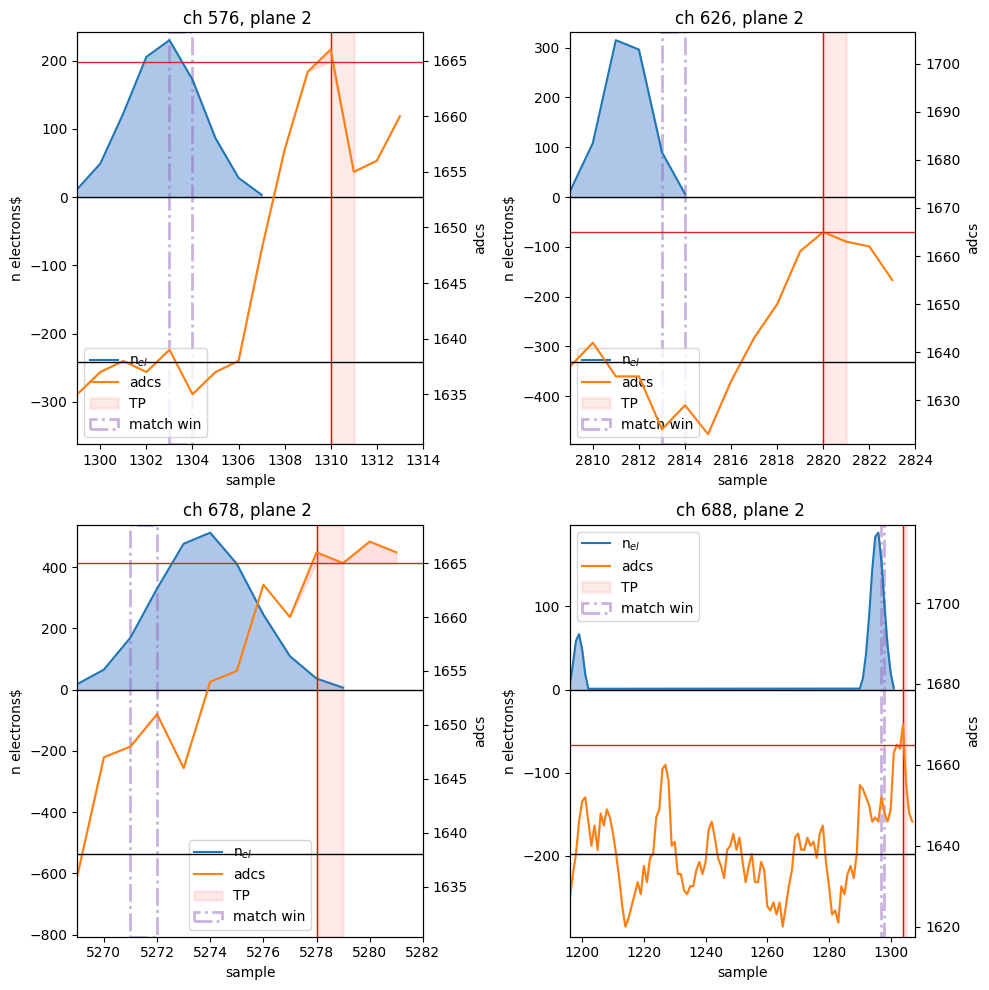

In [72]:
some_tps = ws.tps.query('entry==0 & readout_plane_id==2 & TPCSetID == 0 & samples_over_threshold == 1 & bt_is_signal==1').iloc[0:4]
display(some_tps)
btp.plot_tps_vs_ides(some_tps)

# Check for signs of activity in waveforms

In [83]:
from tpvalidator.detector_geometry import FDVDGeometry_1x8x14


chans = [c for c in ar39_wf.columns if c not in ('event', 'run', 'subrun', 'sample_id')]
loc_chans = [c %  FDVDGeometry_1x8x14.crp_tot_num_chans_sim for c in chans]

crp_view_bins = [
    0,
    FDVDGeometry_1x8x14.crp_view_0_num_chans_sim,
    FDVDGeometry_1x8x14.crp_view_0_num_chans_sim+FDVDGeometry_1x8x14.crp_view_1_num_chans_sim,            
    FDVDGeometry_1x8x14.crp_view_0_num_chans_sim+FDVDGeometry_1x8x14.crp_view_1_num_chans_sim+FDVDGeometry_1x8x14.crp_view_2_num_chans_sim,
]

chan_view = [v-1 for v in np.digitize(loc_chans, crp_view_bins)]


chan_view_map = {c:int(v) for c,v in zip(chans, chan_view)}


/var/folders/dw/sj94s2457kl2gkb829ty4_cc0000gn/T/ipykernel_52475/2770381252.py:41: RuntimeWarning: invalid value encountered in scalar divide
  norm_hist = total_hist / np.sum(total_hist)


[7200. 7204. 7208. 7212. 7216. 7220. 7224. 7228. 7232. 7236. 7240. 7244.
 7248. 7252. 7256. 7260. 7264. 7268. 7272. 7276. 7280. 7284. 7288. 7292.
 7296. 7300. 7304. 7308. 7312. 7316. 7320. 7324. 7328. 7332. 7336. 7340.
 7344. 7348. 7352. 7356. 7360. 7364. 7368. 7372. 7376. 7380. 7384. 7388.
 7392. 7396. 7400. 7404. 7408. 7412. 7416. 7420. 7424. 7428. 7432. 7436.
 7440. 7444. 7448. 7452. 7456. 7460. 7464. 7468. 7472. 7476. 7480. 7484.
 7488. 7492. 7496. 7500. 7504. 7508. 7512. 7516. 7520. 7524. 7528. 7532.
 7536. 7540.] nan

ValueError: x and y must have same first dimension, but have shapes (85,) and (1,)

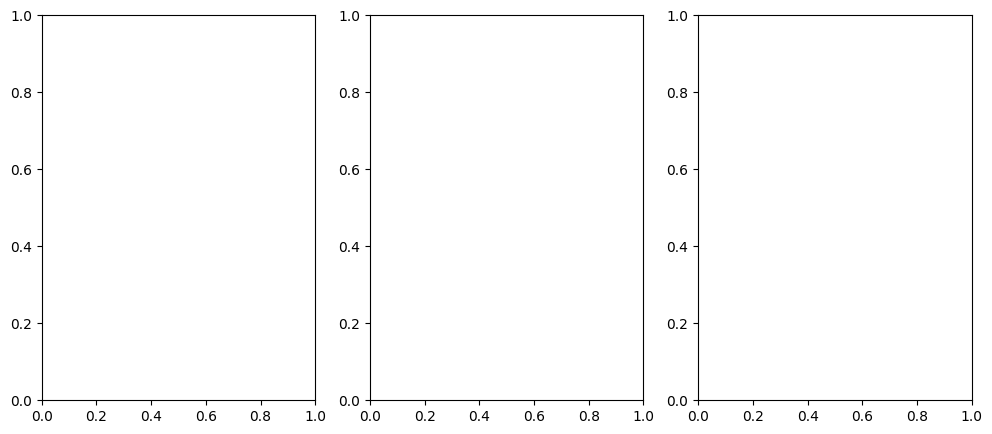

In [ ]:
from tpvalidator.detector_geometry import FDVDGeometry_1x8x14
from tpvalidator.viz.histograms import hist_and_sum


wf_chans = [c for c in ar39_wf.columns if c not in ('event', 'run', 'subrun', 'sample_id')]
loc_chans = [c %  FDVDGeometry_1x8x14.crp_tot_num_chans_sim for c in wf_chans]

tpc_view_bins = [
    0,
    FDVDGeometry_1x8x14.tpc_view_0_num_chans_sim,
    FDVDGeometry_1x8x14.tpc_view_0_num_chans_sim+FDVDGeometry_1x8x14.tpc_view_1_num_chans_sim,            
    FDVDGeometry_1x8x14.tpc_view_0_num_chans_sim+FDVDGeometry_1x8x14.tpc_view_1_num_chans_sim+FDVDGeometry_1x8x14.tpc_view_2_num_chans_sim,
]

chan_view = [v-1 for v in np.digitize(loc_chans, tpc_view_bins)]


chan_view_map = {c:int(v) for c,v in zip(wf_chans, chan_view)}
bins_v2 = np.linspace(1580, 1860, 71)
bins_v2 = np.arange(1580, 2000,4)
bins_v01 = np.linspace(7200, 7540, 86)

boundary = 100

queries = [
    f'sample_id < {boundary}',
    f'sample_id > {boundary}',
]


fig, axes = plt.subplots(1,3, figsize=(12, 5))

print(q)

for v in range(3):
    ax = axes[v]
    chans = [c for c in wf_chans if chan_view_map[c] == v]
    bins = bins_v01 if v in [0,1] else bins_v2

    for q in queries:
        hists, total_hist = hist_and_sum(ar39_wf.query(q), chans, bins)
        norm_hist = total_hist / np.sum(total_hist)
        print(bins, norm_hist)
        ax.step(bins[:-1], norm_hist, where='mid', label=q)

    ax.set_xlabel("Value")
    ax.set_ylabel("Counts")
    ax.set_yscale("log")
    ax.set_title(f"view {v}")
    ax.legend()

fig.suptitle(f"ADC distribution in time bins")
fig.tight_layout()



# Radiologicals

In [ ]:
with temporary_log_level(workspace.TriggerPrimitivesWorkspace._log, logging.INFO):
    rad_ws = workspace.TriggerPrimitivesWorkspace("../../data/vd/bkg/100events/trigtree_tpg_vd_radiols.root")

print(rad_ws.info)

INFO:TriggerPrimitivesWorkspace:Opening Trigger Primitives file
INFO:TriggerPrimitivesWorkspace:Adding processing info
INFO:TriggerPrimitivesWorkspace:Adding Event Summary data
INFO:TriggerPrimitivesWorkspace:triggerAna/event_summary found with 100 rows
INFO:TriggerPrimitivesWorkspace:Adding MCTruth data
INFO:TriggerPrimitivesWorkspace:triggerAna/mctruths found with 7429070 rows
INFO:TriggerPrimitivesWorkspace:Adding MCNeutrino data
INFO:TriggerPrimitivesWorkspace:triggerAna/mcneutrinos found with 0 rows
INFO:TriggerPrimitivesWorkspace:Adding MCParticles data
INFO:TriggerPrimitivesWorkspace:triggerAna/mcparticles found with 7429101 rows
INFO:TriggerPrimitivesWorkspace:Adding IDEs data
INFO:TriggerPrimitivesWorkspace:triggerAna/simides found with 46831493 rows
INFO:TriggerPrimitivesWorkspace:tpmakerTPCSimpleThreshold__TriggerPrimitiveMaker found with 1552294 rows


None

{
    'backtracker': {'TPAlgTPCSimpleThreshold': {'offset_U': 8, 'offset_V': 1, 'offset_X': -7}},
    'geo': {'detector': 'dunevd10kt_3view_30deg_v5_refactored_1x8x6ref'},
    'tpg': {
        'tpmakerTPCSimpleThreshold::TriggerPrimitiveMaker': {
            'threshold_tpg_plane0': 38,
            'threshold_tpg_plane1': 38,
            'threshold_tpg_plane2': 44,
            'tool': 'TPAlgTPCSimpleThreshold'
        }
    }
}

In [ ]:
rad_ws.add_rawdigits('../../data/vd/bkg/100events/trigger_digits_waves_detsim_vd_radiols.root')

In [ ]:
rad_wf = rad_ws.get_rawadcs(1)

[1]

1

/Users/ale/Development/dune/trigger-studies/tpvalidator/src/tpvalidator/mcprod/workspace.py:510: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



In [85]:
from tpvalidator.detector_geometry import FDVDGeometry_1x8x14
from tpvalidator.viz.histograms import hist_and_sum

wf_chans = [c for c in rad_wf.columns if c not in ('event', 'run', 'subrun', 'sample_id')]
loc_chans = [c %  FDVDGeometry_1x8x14.crp_tot_num_chans_sim for c in wf_chans]

tpc_view_bins = [
    0,
    FDVDGeometry_1x8x14.tpc_view_0_num_chans_sim,
    FDVDGeometry_1x8x14.tpc_view_0_num_chans_sim+FDVDGeometry_1x8x14.tpc_view_1_num_chans_sim,            
    FDVDGeometry_1x8x14.tpc_view_0_num_chans_sim+FDVDGeometry_1x8x14.tpc_view_1_num_chans_sim+FDVDGeometry_1x8x14.tpc_view_2_num_chans_sim,
]

chan_view = [v-1 for v in np.digitize(loc_chans, tpc_view_bins)]


chan_view_map = {c:int(v) for c,v in zip(wf_chans, chan_view)}
bins_v2 = np.linspace(1580, 1860, 71)
bins_v2 = np.arange(1580, 2000,4)
bins_v01 = np.linspace(7200, 7540, 86)

# ro_view = 1
# chans = [c for c in wf_chans if chan_view_map[c] == ro_view]
# bins = bins_v01 if ro_view in [0,1] else bins_v2

boundary = 100


queries = [
    f'sample_id < {boundary}',
    f'sample_id > {boundary}',
    # f'sample_id > 5000'
]


fig, axes = plt.subplots(1,3, figsize=(12, 5))


for v in range(3):
    ax = axes[v]
    chans = [c for c in wf_chans if chan_view_map[c] == v]
    bins = bins_v01 if v in [0,1] else bins_v2

    for q in queries:
        hists, total_hist = hist_and_sum(rad_wf.query(q), chans, bins)
        # print(total_hist)
        norm_hist = total_hist / np.sum(total_hist)
        # print(norm_hist)

        ax.step(bins[:-1], norm_hist, where='mid', label=q)

    ax.set_xlabel("Value")
    ax.set_ylabel("Counts")
    ax.set_yscale("log")
    ax.set_title(f"view {v}")

    plt.legend()
fig.suptitle(f"ADC distribution in time bins")
fig.tight_layout()



NameError: name 'rad_wf' is not defined